# Learn neural ODEs with diffusion tempering


In [1]:
"""Train a neural ODE with ProbDiffEq and Optax using diffusion tempering."""

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax

from probdiffeq import ivpsolve, probdiffeq

# Fail this notebook on NaN detection (to catch those in the CI)
jax.config.update("jax_debug_nans", True)


def main(num_data=100, epochs=1000, print_every=100, hidden=(20,), lr=0.2) -> None:
    """Train a neural ODE using diffusion tempering."""
    # Create some data and construct a neural ODE
    grid = jnp.linspace(0, 1, num=num_data)
    data = jnp.sin(2.5 * jnp.pi * grid) * jnp.pi * grid
    std = 1e-1
    output_scale = 1e1
    vf, u0, (t0, _t1), f_args = vf_neural_ode(hidden=hidden, t0=0.0, t1=1)

    # Create a loss (this is where probabilistic numerics enters!)
    loss = loss_log_marginal_likelihood(vf=vf, t0=t0)
    loss0, info0 = loss(
        f_args, u0=u0, grid=grid, data=data, std=std, output_scale=output_scale
    )

    # Plot the data and the initial guess
    plt.title(f"Initial estimate | Loss: {loss0:.2f}")
    plt.plot(grid, data, "x", label="Data", color="C0")
    plt.plot(grid, info0["sol"].u.mean[0], "-", label="Estimate", color="C1")
    plt.legend()
    plt.show()

    # Construct an optimiser
    optim = optax.adam(lr)
    train_step = train_step_optax(optim, loss=loss)

    # Train the model
    state = optim.init(f_args)
    print("Loss after...")
    for i in range(epochs):
        (f_args, state), info = train_step(
            f_args,
            state,
            u0=u0,
            grid=grid,
            data=data,
            std=std,
            output_scale=output_scale,
        )

        # Print progressbar
        if i % print_every == print_every - 1:
            print(f"...{(i + 1)} epochs: loss={info['loss']:.7e}")

        # Diffusion tempering: https://arxiv.org/abs/2402.12231
        # To all users: Adjust this tempering and
        # see how it affects parameter estimation.
        if i % 100 == 99:
            output_scale /= 10.0

    # Plot the results
    plt.title(f"Final estimate | Loss: {info['loss']:.2f}")
    plt.plot(grid, data, "x", label="Data", color="C0")
    plt.plot(grid, info0["sol"].u.mean[0], "-", label="Initial estimate", color="C1")
    plt.plot(grid, info["sol"].u.mean[0], "-", label="Final estimate", color="C2")
    plt.legend()
    plt.show()

In [2]:
def vf_neural_ode(*, hidden: tuple, t0: float, t1: float):
    """Build a neural ODE."""
    f_args, mlp = model_mlp(hidden=hidden, shape_in=(2,), shape_out=(1,))
    u0 = jnp.asarray(0.0)

    @jax.jit
    def vf(y, /, *, t, p):
        """Evaluate the neural ODE vector field."""
        y_and_t = jnp.concatenate([y[None], t[None]])
        return mlp(p, y_and_t)

    return vf, (u0,), (t0, t1), f_args

In [3]:
def model_mlp(
    *, hidden: tuple, shape_in: tuple = (), shape_out: tuple = (), activation=jnp.tanh
):
    """Construct an MLP."""
    assert len(shape_in) <= 1
    assert len(shape_out) <= 1

    shape_prev = shape_in
    weights = []
    for h in hidden:
        W = jnp.empty((h, *shape_prev))
        b = jnp.empty((h,))
        shape_prev = (h,)
        weights.append((W, b))

    W = jnp.empty((*shape_out, *shape_prev))
    b = jnp.empty(shape_out)
    weights.append((W, b))

    p_flat, unravel = jax.flatten_util.ravel_pytree(weights)

    def fwd(w, x):
        for A, b in w[:-1]:
            x = jnp.dot(A, x) + b
            x = activation(x)

        A, b = w[-1]
        return jnp.dot(A, x) + b

    key = jax.random.PRNGKey(1)
    p_init = jax.random.normal(key, shape=p_flat.shape, dtype=p_flat.dtype)
    return unravel(p_init), fwd

In [4]:
def loss_log_marginal_likelihood(vf, *, t0):
    """Build a loss function from an ODE problem."""

    @jax.jit
    def loss(
        p: jax.Array,
        *,
        u0: tuple,
        grid: jax.Array,
        data: jax.Array,
        std: jax.Array,
        output_scale: jax.Array,
    ):
        """Loss function: log-marginal likelihood of the data."""
        # Build a solver
        tcoeffs = (*u0, vf(*u0, t=t0, p=p))
        init, ssm = probdiffeq.ssm_taylor(tcoeffs, ssm_fact="dense")
        iwp = probdiffeq.prior_wiener_integrated(ssm=ssm, output_scale=output_scale)

        def vf_p(y, /, *, t):
            return vf(y, t=t, p=p)

        ts0 = probdiffeq.constraint_ode_ts0(vf_p, ssm=ssm)
        strategy = probdiffeq.strategy_smoother_fixedinterval(ssm=ssm)
        solver_ts0 = probdiffeq.solver(
            strategy=strategy, prior=iwp, constraint=ts0, ssm=ssm
        )

        # Solve
        solve = ivpsolve.solve_fixed_grid(solver=solver_ts0)
        sol = solve(init, grid=grid)

        # Evaluate loss
        loss_lml = probdiffeq.loss_lml_timeseries(ssm=ssm)
        std = jnp.ones_like(grid)[:, None] * std[None, None]

        lml = loss_lml(data, std=std, posterior=sol.solution_full)
        return -lml, {"sol": sol}

    return loss

In [5]:
def train_step_optax(optimizer, loss):
    """Implement a training step using Optax."""

    @jax.jit
    def update(params, opt_state, **loss_kwargs):
        """Update the optimiser state."""
        value_and_grad = jax.value_and_grad(loss, argnums=0, has_aux=True)
        (value, info), grads = value_and_grad(params, **loss_kwargs)
        updates, opt_state = optimizer.update(grads, opt_state)
        params = optax.apply_updates(params, updates)

        return (params, opt_state), {"sol": info["sol"], "loss": value}

    return update

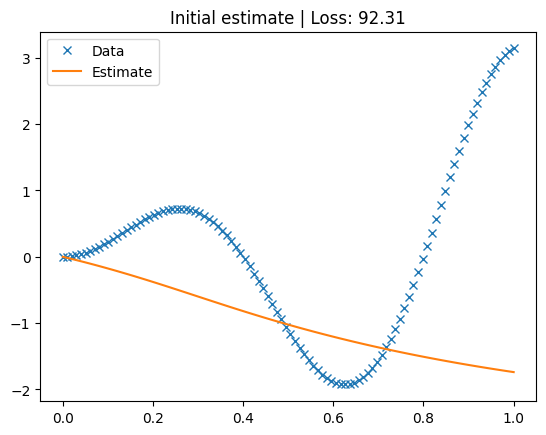

Loss after...


...100 epochs: loss=1.6423046e+01
...200 epochs: loss=1.6325195e+01
...300 epochs: loss=-2.9036382e-01


...400 epochs: loss=-1.2700549e-01
...500 epochs: loss=-1.0543542e+00
...600 epochs: loss=-1.1525428e+00


...700 epochs: loss=-1.2112830e+00
...800 epochs: loss=-1.2397795e+00
...900 epochs: loss=-1.0868592e+00


...1000 epochs: loss=-1.3142933e+00


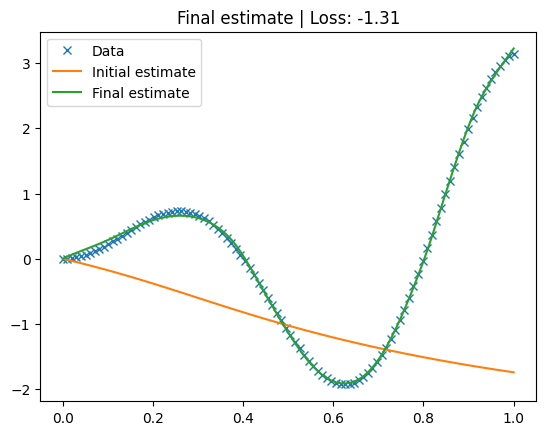

In [6]:
if __name__ == "__main__":
    main()